# Alps DEM — Data Exploration

This notebook explores the Italian Alps Digital Elevation Model (GeoTIFF) data:
metadata inspection, data validation, descriptive statistics, and visualization.

**Data source:** NASADEM / SRTM-like, ~30 m/px, EPSG:4326
**Region:** Northern Italy (Ortler Alps area)

In [1]:
# Import core libraries
import rasterio                      # Read GeoTIFF raster files
import numpy as np                   # Numerical array operations
import matplotlib.pyplot as plt      # Plotting and visualization

# Path to the DEM file (relative to this notebook)
DEM_PATH = "../data/output_be.tif"

## 1. Metadata Inspection

Extract the file's essential metadata: dimensions, coordinate reference system,
geographic bounds, spatial resolution, and nodata value..

In [2]:

# Open the GeoTIFF and print its metadata
with rasterio.open(DEM_PATH) as src:
    print("Width:   ", src.width)        # Image width in pixels
    print("Height:  ", src.height)       # Image height in pixels
    print("Count:   ", src.count)        # Number of bands (1 for DEM)
    print("Dtype:   ", src.dtypes)       # Data type per band
    print("CRS:     ", src.crs)          # Coordinate reference system
    print("Bounds:  ", src.bounds)       # Geographic extent
    print("Res:     ", src.res)          # Pixel resolution (degrees)
    print("Nodata:  ", src.nodata)       # Declared nodata value

Width:    6763
Height:   4545
Count:    1
Dtype:    ('int16',)
CRS:      EPSG:4326
Bounds:   BoundingBox(left=9.892916666691775, bottom=45.550972222220175, right=11.771527777803136, top=46.81347222222034)
Res:      (0.0002777777777778147, 0.0002777777777778147)
Nodata:   -32768.0


## 1. Metadata Inspection

Extract the file's essential metadata: dimensions, coordinate reference system,
geographic bounds, spatial resolution, and nodata value.

In [3]:
# Read the first (and only) band into a NumPy array
with rasterio.open(DEM_PATH) as src:
    data = src.read(1)                   # Read band 1 → 2D array

# Inspect the resulting array
print("Array shape:", data.shape)        # (height, width) = (4545, 6763)
print("Array dtype:", data.dtype)        # int16

# Verify nodata pixels (file declares -32768 but may have none)
nodata_count = (data == -32768).sum()
print("Nodata pixel count:", nodata_count)

Array shape: (4545, 6763)
Array dtype: int16
Nodata pixel count: 0


## 3. Descriptive Statistics

Compute the elevation distribution's core statistics:
minimum, maximum, mean, median, and standard deviation.

In [4]:
# Compute basic descriptive statistics on the elevation data
print(f"Min:    {np.min(data)} m")
print(f"Max:    {np.max(data)} m")
print(f"Mean:   {np.mean(data):.2f} m")
print(f"Median: {np.median(data):.2f} m")
print(f"Std:    {np.std(data):.2f} m")

Min:    -6 m
Max:    3985 m
Mean:   1418.11 m
Median: 1394.00 m
Std:    805.33 m


## 4. Visualization

Render the elevation map using the "terrain" colormap, which maps
low values to blue (water), mid-range values to green and brown,
and high peaks to white (snow-capped mountains).

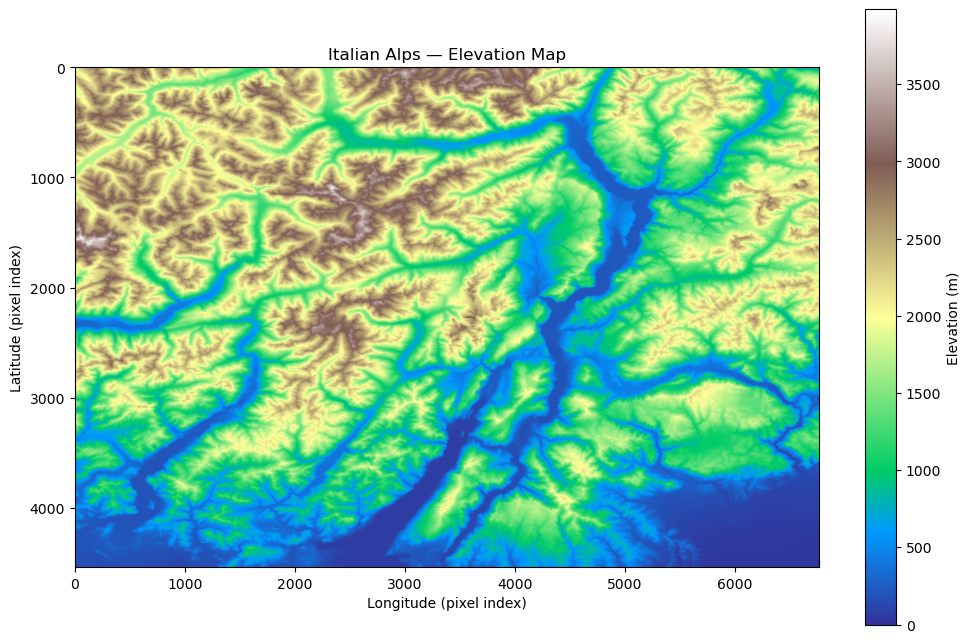

In [5]:
# Plot the elevation map with a terrain colormap
plt.figure(figsize=(12, 8))                          # Larger figure for clarity
plt.imshow(data, cmap='terrain')                     # Render array as image
plt.colorbar(label="Elevation (m)")                  # Add color scale
plt.title("Italian Alps — Elevation Map")            # Figure title
plt.xlabel("Longitude (pixel index)")
plt.ylabel("Latitude (pixel index)")
plt.show()